## Main Code

In [ ]:
!pip install torchvision Pillow scikit-learn grad-cam matplotlib

import os
import torch
from torch import nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/DRProject/New Dataset unique.csv",
    header=None,
    names=["SubjectID", "Gender", "Age", "HbA1c"]
)

df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})
df[['Gender','Age','HbA1c']] = df[['Gender','Age','HbA1c']].apply(
    pd.to_numeric, errors='coerce'
)

images_dir = '/content/drive/MyDrive/DRProject/NEW Funduses'


Mounted at /content/drive


In [ ]:
class BilateralFilterTransform:
    def __call__(self, img):
        img_np = np.array(img)
        img_np = cv2.bilateralFilter(img_np, d=9, sigmaColor=75, sigmaSpace=75)
        return Image.fromarray(img_np)


In [ ]:
base_transform = transforms.Compose([
    BilateralFilterTransform(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

augmentation_transform = transforms.Compose([
    BilateralFilterTransform(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(0.1,0.1,0.1,0.1),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
class FundusDataset(torch.utils.data.Dataset):
    def __init__(self, df, images_dir, transform):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        subject_id = self.df.loc[idx, 'SubjectID']
        img_path = os.path.join(self.images_dir, f"{subject_id}.jpg")

        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)

        # 🔥 FORCE NUMERIC TYPES (prevents numpy.object_ bug)
        meta = self.df.loc[idx, ['Gender', 'Age']].astype(np.float32).values
        meta = torch.tensor(meta, dtype=torch.float32)

        target = torch.tensor(
            float(self.df.loc[idx, 'HbA1c']),
            dtype=torch.float32
        )

        return image, meta, target


In [ ]:
from torchvision import models
from torch import nn

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Identity()   # Remove classifier
model.to(device)
model.eval()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
from sklearn.model_selection import LeaveOneOut
from collections import defaultdict

loo = LeaveOneOut()

predictions = []
actuals = []

AUG_PER_IMAGE = 50
ridge = Ridge(alpha=4.5)

# -----------------------------------
# STEP 1: CACHE IMAGE FEATURES ONLY (NO METADATA)
# -----------------------------------

FEATURE_CACHE = {}

for idx in range(len(df)):
    row = df.iloc[idx]
    sid = row['SubjectID']

    feats = []

    for _ in range(AUG_PER_IMAGE + 1):
        img = Image.open(
            os.path.join(images_dir, f"{sid}.jpg")
        ).convert('RGB')

        img = augmentation_transform(img)

        with torch.no_grad():
            img = img.unsqueeze(0).to(device)
            feat = model(img).cpu().numpy().flatten()

        feats.append(feat)

    # 🔥 IMPORTANT: Average augmented embeddings (one feature per subject)
    FEATURE_CACHE[sid] = np.mean(feats, axis=0)

# -----------------------------------
# STEP 2: LOOCV (NO DUPLICATION BIAS)
# -----------------------------------

for train_idx, test_idx in loo.split(df):

    train_df = df.iloc[train_idx].copy()
    test_df  = df.iloc[test_idx].copy()

    # 🔥 Normalize AGE inside fold (prevents leakage)
    scaler = StandardScaler()
    train_df[['Age']] = scaler.fit_transform(train_df[['Age']])
    test_df[['Age']]  = scaler.transform(test_df[['Age']])

    X_train, y_train = [], []

    for _, row in train_df.iterrows():
        sid = row['SubjectID']
        img_feat = FEATURE_CACHE[sid]
        meta = row[['Gender', 'Age']].values.astype(np.float32)
        X_train.append(np.hstack([img_feat, meta]))
        y_train.append(row['HbA1c'])

    X_train = np.array(X_train)
    y_train = np.array(y_train)

    # Test
    test_row = test_df.iloc[0]
    test_sid = test_row['SubjectID']

    img_feat = FEATURE_CACHE[test_sid]
    meta = test_row[['Gender', 'Age']].values.astype(np.float32)

    X_test = np.hstack([img_feat, meta]).reshape(1, -1)
    y_true = test_row['HbA1c']

    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)[0]

    predictions.append(y_pred)
    actuals.append(y_true)


In [ ]:
actuals_cv = np.array(actuals)
predictions_cv = np.array(predictions)


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Metrics
mae = mean_absolute_error(actuals_cv, predictions_cv)
rmse = np.sqrt(mean_squared_error(actuals_cv, predictions_cv))
r2 = r2_score(actuals_cv, predictions_cv)

# Print results
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


MAE  : 0.919
RMSE : 1.275
R²   : 0.592


In [ ]:
# -----------------------------------
# BOOTSTRAP 95% CONFIDENCE INTERVALS
# -----------------------------------

def bootstrap_ci(y_true, y_pred, metric_func, n_boot=2000):
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = np.random.choice(range(n), n, replace=True)
        scores.append(metric_func(y_true[idx], y_pred[idx]))
    return np.percentile(scores, [2.5, 97.5])

print("\n95% Confidence Intervals:")
print("MAE :", bootstrap_ci(actuals_cv, predictions_cv, mean_absolute_error))
print("RMSE:", bootstrap_ci(actuals_cv, predictions_cv,
                             lambda y,p: np.sqrt(mean_squared_error(y,p))))
print("R2  :", bootstrap_ci(actuals_cv, predictions_cv, r2_score))



95% Confidence Intervals:
MAE : [0.62685769 1.3037334 ]
RMSE: [0.75762842 1.76801021]
R2  : [0.29651613 0.83171314]


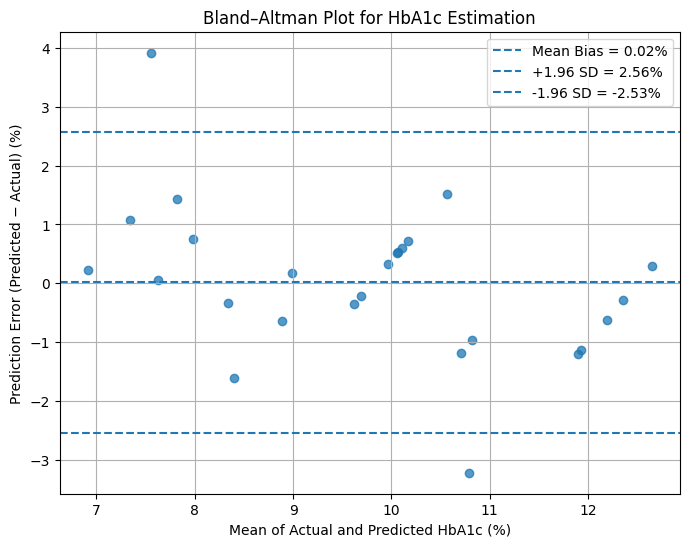


Bland–Altman Statistics:
Mean Bias: 0.016
Upper LoA: 2.564
Lower LoA: -2.531


In [ ]:
# =========================================================
# BLAND–ALTMAN AGREEMENT ANALYSIS
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# Mean of measurements
mean_vals = (actuals_cv + predictions_cv) / 2

# Signed differences (NOT absolute)
differences = predictions_cv - actuals_cv

# Mean bias
mean_bias = np.mean(differences)

# Standard deviation of differences
std_diff = np.std(differences, ddof=1)

# 95% Limits of Agreement
upper_loa = mean_bias + 1.96 * std_diff
lower_loa = mean_bias - 1.96 * std_diff

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(mean_vals, differences, alpha=0.75)

plt.axhline(mean_bias, linestyle='--',
            label=f'Mean Bias = {mean_bias:.2f}%')

plt.axhline(upper_loa, linestyle='--',
            label=f'+1.96 SD = {upper_loa:.2f}%')

plt.axhline(lower_loa, linestyle='--',
            label=f'-1.96 SD = {lower_loa:.2f}%')

plt.xlabel('Mean of Actual and Predicted HbA1c (%)')
plt.ylabel('Prediction Error (Predicted − Actual) (%)')
plt.title('Bland–Altman Plot for HbA1c Estimation')
plt.legend()
plt.grid(True)
plt.show()

print("\nBland–Altman Statistics:")
print(f"Mean Bias: {mean_bias:.3f}")
print(f"Upper LoA: {upper_loa:.3f}")
print(f"Lower LoA: {lower_loa:.3f}")


In [ ]:
def clarke_error_grid_hba1c(actual, pred):
    zones = []

    for a, p in zip(actual, pred):
        diff = abs(a - p)

        if diff <= 0.5:
            zones.append('A')
        elif diff <= 1.0:
            zones.append('B')
        elif diff <= 2.0:
            zones.append('C')
        else:
            zones.append('D')

    return zones


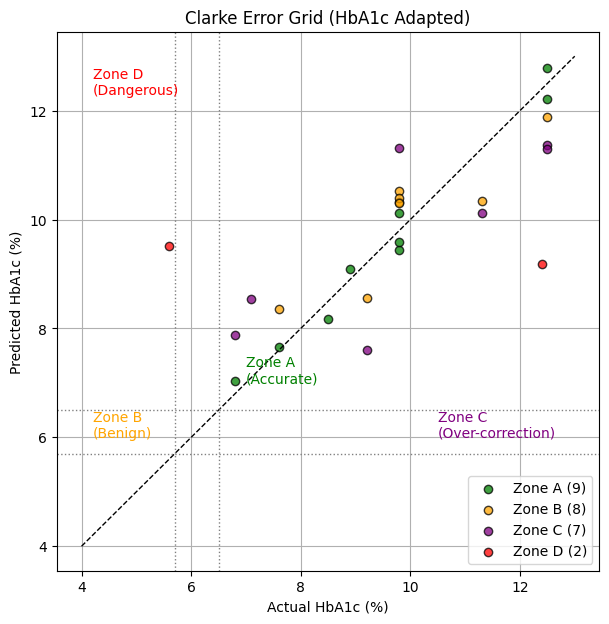

Counter({'A': 9, 'B': 8, 'C': 7, 'D': 2})


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

actuals_cv = np.array(actuals_cv)
predictions_cv = np.array(predictions_cv)

zones = clarke_error_grid_hba1c(actuals_cv, predictions_cv)
zone_counts = Counter(zones)

# Color map for zones
zone_colors = {
    'A': 'green',
    'B': 'orange',
    'C': 'purple',
    'D': 'red'
}

plt.figure(figsize=(7,7))

# Plot points by zone
for zone in zone_colors:
    idx = [i for i, z in enumerate(zones) if z == zone]
    plt.scatter(
        actuals_cv[idx],
        predictions_cv[idx],
        c=zone_colors[zone],
        label=f'Zone {zone} ({zone_counts.get(zone,0)})',
        alpha=0.75,
        edgecolors='k'
    )

# Identity line
plt.plot([4, 13], [4, 13], 'k--', linewidth=1)

# HbA1c diagnostic thresholds
plt.axvline(5.7, color='gray', linestyle=':', linewidth=1)
plt.axvline(6.5, color='gray', linestyle=':', linewidth=1)
plt.axhline(5.7, color='gray', linestyle=':', linewidth=1)
plt.axhline(6.5, color='gray', linestyle=':', linewidth=1)

# Region labels
plt.text(4.2, 12.3, 'Zone D\n(Dangerous)', color='red')
plt.text(4.2, 6.0, 'Zone B\n(Benign)', color='orange')
plt.text(7.0, 7.0, 'Zone A\n(Accurate)', color='green')
plt.text(10.5, 6.0, 'Zone C\n(Over-correction)', color='purple')

plt.xlabel('Actual HbA1c (%)')
plt.ylabel('Predicted HbA1c (%)')
plt.title('Clarke Error Grid (HbA1c Adapted)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print(zone_counts)


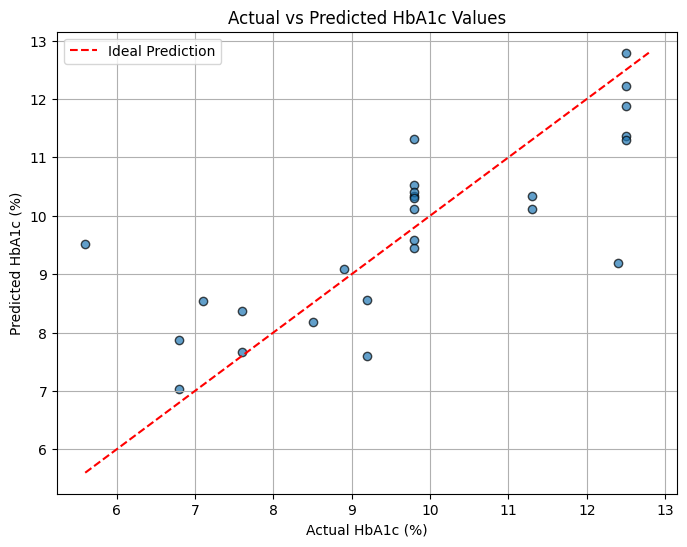

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(actuals_cv, predictions_cv, alpha=0.7, edgecolors='k')

# Ideal prediction line (y = x)
min_val = min(actuals_cv.min(), predictions_cv.min())
max_val = max(actuals_cv.max(), predictions_cv.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', label='Ideal Prediction')

plt.title('Actual vs Predicted HbA1c Values')
plt.xlabel('Actual HbA1c (%)')
plt.ylabel('Predicted HbA1c (%)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
df_full = df.copy()

scaler_full = StandardScaler()
df_full[['Age']] = scaler_full.fit_transform(df_full[['Age']])

X_full, y_full = [], []

for _, row in df_full.iterrows():
    sid = row['SubjectID']
    img_feat = FEATURE_CACHE[sid]
    meta = row[['Gender','Age']].values.astype(np.float32)
    X_full.append(np.hstack([img_feat, meta]))
    y_full.append(row['HbA1c'])

X_full = np.array(X_full)
y_full = np.array(y_full)

ridge_final = Ridge(alpha=4.5)
ridge_final.fit(X_full, y_full)

print("Final model trained.")


Final model trained.


In [ ]:
def predict_hba1c(image_path, gender, age):

    image = Image.open(image_path).convert('RGB')
    image = base_transform(image)
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        img_features = model(image).cpu().numpy().flatten()

    gender_code = 1 if gender.upper()=='M' else 0
    age_norm = scaler_full.transform([[age]])[0][0]

    meta = np.array([gender_code, age_norm], dtype=np.float32)
    features = np.hstack([img_features, meta]).reshape(1,-1)

    pred = ridge_final.predict(features)[0]
    return pred


In [ ]:
predict_hba1c(
    image_path="/content/drive/MyDrive/DRProject/NEW Funduses/Pt15.jpg",
    gender="M",
    age=46
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float32(11.535261)

In [ ]:
results = []

for _, row in df.iterrows():

    image_path = f"{images_dir}/{row['SubjectID']}.jpg"

    img = Image.open(image_path).convert('RGB')
    img = base_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        img_feat = model(img).cpu().numpy().flatten()

    age_norm = scaler_full.transform(
    pd.DataFrame([[age]], columns=['Age'])
)[0][0]

    meta = np.array([row['Gender'], age_norm], dtype=np.float32)

    features = np.hstack([img_feat, meta]).reshape(1,-1)
    pred = ridge_final.predict(features)[0]

    results.append([
        row['SubjectID'],
        row['Gender'],
        row['Age'],
        row['HbA1c'],
        pred
    ])

results_df = pd.DataFrame(results,
    columns=['PatientID','Gender','Age','Actual HbA1c','Predicted HbA1c'])

results_df


,PatientID,Gender,Age,Actual HbA1c,Predicted HbA1c
0,Pt01,0,40,5.6,6.294318
1,Pt02,1,70,7.6,7.989419
2,Pt03,1,70,7.6,7.608149
3,Pt04,1,43,6.8,6.794704
4,Pt05,1,43,6.8,7.486253
5,Pt06,1,40,9.2,9.598891
6,Pt07,1,40,9.2,10.608437
7,Pt08,1,40,9.8,9.339264
8,Pt09,0,45,9.8,9.831753
9,Pt10,1,50,9.8,9.170141


In [ ]:
results_df.to_csv("HbA1c_Predictions_All_Patients.csv", index=False)


In [ ]:
actuals_full = results_df['Actual HbA1c'].values
predictions_full = results_df['Predicted HbA1c'].values
errors = predictions_full - actuals_full

var_actual = np.var(actuals, ddof=1)
var_predicted = np.var(predictions, ddof=1)
var_error = np.var(errors, ddof=1)

print(f"Variance of Actual HbA1c     : {var_actual:.3f}")
print(f"Variance of Predicted HbA1c  : {var_predicted:.3f}")
print(f"Variance of Prediction Error: {var_error:.3f}")


Variance of Actual HbA1c     : 4.138
Variance of Predicted HbA1c  : 2.311
Variance of Prediction Error: 0.667


In [ ]:
import torch

# Save only the model weights (recommended)
torch.save(model.state_dict(), "resnet18_feature_extractor.pth")


In [ ]:
import joblib

joblib.dump(ridge, "ridge_hba1c_model.pkl")


['ridge_hba1c_model.pkl']

In [ ]:
from google.colab import files

files.download("resnet18_feature_extractor.pth")
files.download("ridge_hba1c_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>